In [33]:
import numpy as np
import torch
import rasterio
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import uniform_filter, binary_opening
import json

RAW       = Path("data/raw")
label_dir = RAW / "label"
device    = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

def pair_image_label(img_path, label_dir):
    stem = img_path.stem.replace("_nonorm_bands20m", "")
    return Path(label_dir) / f"{stem}_bin_label.tiff"

class MethaneSegDataset(Dataset):
    def __init__(self, dataframe, label_dir):
        self.df        = dataframe.reset_index(drop=True)
        self.label_dir = Path(label_dir)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = row["path"]
        lbl_path = pair_image_label(img_path, self.label_dir)
        eps      = 1e-6

        with rasterio.open(img_path) as src:
            img = src.read().astype(np.float32)

        b11, b12 = img[11], img[12]

        def norm(x):
            lo, hi = np.percentile(x, 2), np.percentile(x, 98)
            return np.clip((x - lo) / (hi - lo + eps), 0, 1).astype(np.float32)

        b11_n = norm(b11)
        b12_n = norm(b12)
        ratio = np.clip((b12_n + eps) / (b11_n + eps), 0, 5).astype(np.float32)
        diff  = (b12_n - b11_n).astype(np.float32)
        x     = np.stack([b11_n, b12_n, ratio, diff], axis=0)

        with rasterio.open(lbl_path) as src:
            lbl  = src.read(1).astype(np.float32)
        mask = (lbl > 0.5).astype(np.float32)

        return (torch.tensor(x, dtype=torch.float32),
                torch.tensor(mask, dtype=torch.float32).unsqueeze(0))

print("Setup complete")

Device: mps
Setup complete


In [35]:
all_files = sorted(RAW.glob("*.tiff"))
records   = []
for f in all_files:
    main = f.stem.split("___")
    records.append({
        "path"       : f,
        "sample_id"  : int(main[0]),
        "location_id": int(main[1].split("_")[0])
    })

meta_df  = pd.DataFrame(records)
val_df   = meta_df[meta_df["location_id"].isin([8, 9])].reset_index(drop=True)
val_dataset = MethaneSegDataset(val_df, label_dir)
val_loader  = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)
print(f"Val set: {len(val_dataset)} tiles")

Val set: 185 tiles


In [39]:
def evaluate_segmentation(loader, pred_fn, threshold):
    total_iou = total_f1 = total_recall = total_fpr = 0
    n = 0
    for x, mask in loader:
        pred = pred_fn(x, threshold).squeeze().numpy()
        gt   = mask.squeeze().numpy()
        eps  = 1e-6
        tp = ((pred==1) & (gt==1)).sum()
        fp = ((pred==1) & (gt==0)).sum()
        fn = ((pred==0) & (gt==1)).sum()
        tn = ((pred==0) & (gt==0)).sum()
        total_iou    += tp / (tp + fp + fn + eps)
        total_f1     += 2*tp / (2*tp + fp + fn + eps)
        total_recall += tp / (tp + fn + eps)
        total_fpr    += fp / (fp + tn + eps)
        n += 1
    return {
        "IoU"    : round(total_iou    / n, 4),
        "F1"     : round(total_f1     / n, 4),
        "Recall" : round(total_recall / n, 4),
        "FP_rate": round(total_fpr    / n, 4)
    }

print("Evaluation function ready")

Evaluation function ready


In [41]:
# The correct physics insight from literature [Varon et al. 2021, Sentinel-2]:
# Methane ABSORBS B12 → plume pixels have LOWER B12/B11 than surroundings
# So we detect local NEGATIVE anomalies in the ratio channel

def improved_physics_baseline(x_batch, window=15, z_thresh=1.5):
    batch_preds = []
    ratio_np = x_batch[:, 2, :, :].numpy()
    for i in range(ratio_np.shape[0]):
        ratio      = ratio_np[i]
        local_mean = uniform_filter(ratio, size=window)
        local_std  = np.sqrt(uniform_filter((ratio - local_mean)**2, size=window)) + 1e-6
        anomaly    = (ratio - local_mean) / local_std
        pred       = (anomaly < -z_thresh).astype(np.float32)
        pred       = binary_opening(pred, iterations=1).astype(np.float32)
        batch_preds.append(pred)
    return torch.tensor(np.stack(batch_preds)).unsqueeze(1)

print("Improved baseline defined")

Improved baseline defined


In [25]:
# Rebuild meta_df + train/val split (copy from notebook 1 cells 4-6)
# ...then:
train_dataset = MethaneSegDataset(train_df, label_dir)
val_dataset   = MethaneSegDataset(val_df,   label_dir)

val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)
print(f"Val set: {len(val_dataset)} tiles")

Val set: 185 tiles


In [43]:
print("Improved Physics Baseline — z-score threshold sweep:\n")
print(f"{'Z-thresh':>10} | {'IoU':>8} | {'F1':>8} | {'Recall':>8} | {'FP_rate':>8}")
print("-" * 60)

best_f1 = 0
best_z  = 1.5
results = []

for z in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]:
    r = evaluate_segmentation(
        val_loader,
        lambda x, t: improved_physics_baseline(x, window=15, z_thresh=t),
        threshold=z
    )
    marker = " ← best F1" if r["F1"] > best_f1 else ""
    print(f"{z:>10.1f} | {r['IoU']:>8.4f} | {r['F1']:>8.4f} | {r['Recall']:>8.4f} | {r['FP_rate']:>8.4f}{marker}")
    if r["F1"] > best_f1:
        best_f1, best_z = r["F1"], z
    results.append({"z_threshold": z, **r})

print(f"\nBest: z={best_z}, F1={best_f1:.4f}")

Improved Physics Baseline — z-score threshold sweep:

  Z-thresh |      IoU |       F1 |   Recall |  FP_rate
------------------------------------------------------------
       0.5 |   0.0542 |   0.1010 |   0.4323 |   0.0347 ← best F1
       1.0 |   0.1210 |   0.2080 |   0.2203 |   0.0044 ← best F1
       1.5 |   0.0540 |   0.0993 |   0.0641 |   0.0008
       2.0 |   0.0144 |   0.0275 |   0.0153 |   0.0002
       2.5 |   0.0048 |   0.0094 |   0.0049 |   0.0000
       3.0 |   0.0012 |   0.0024 |   0.0012 |   0.0000

Best: z=1.0, F1=0.2080


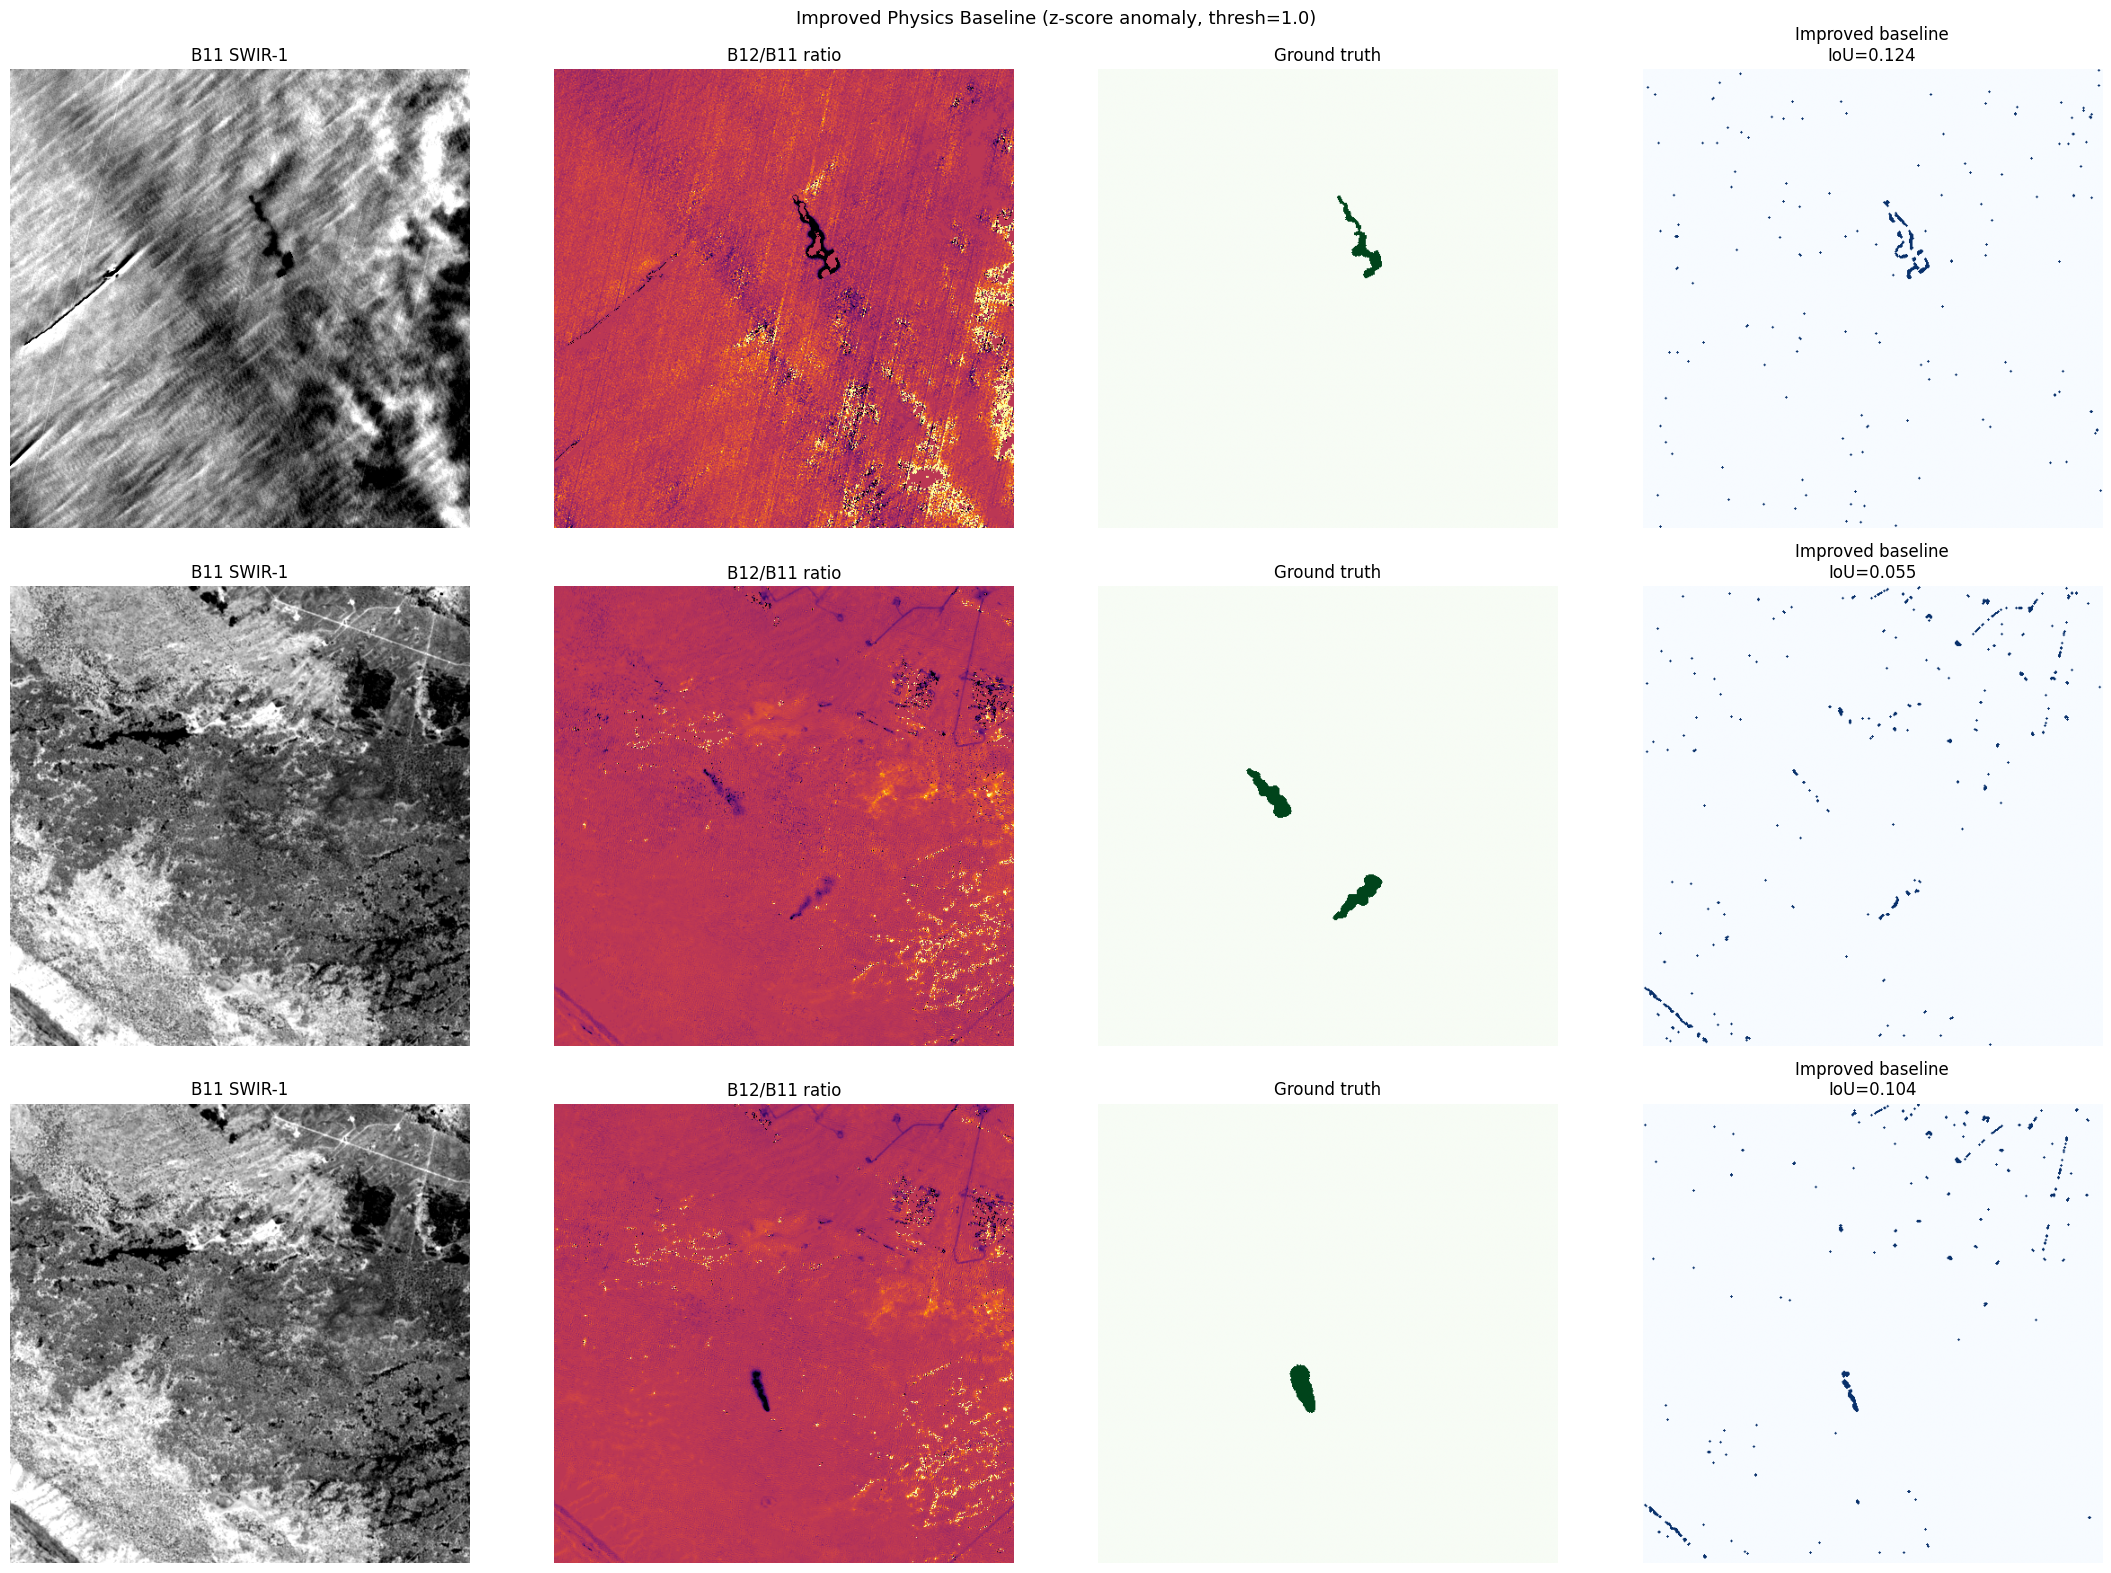

In [45]:
fig, axes = plt.subplots(3, 4, figsize=(22, 16))

for row, idx in enumerate([0, 50, 100]):
    x, mask = val_dataset[idx]
    gt      = mask.squeeze().numpy()
    b11     = x[0].numpy()
    ratio_ch= x[2].numpy()
    pred    = improved_physics_baseline(x.unsqueeze(0), window=15, z_thresh=best_z).squeeze().numpy()

    def iou(p, g):
        eps=1e-6; tp=((p==1)&(g==1)).sum(); fp=((p==1)&(g==0)).sum(); fn=((p==0)&(g==1)).sum()
        return tp/(tp+fp+fn+eps)

    axes[row,0].imshow(b11,      cmap="gray");                  axes[row,0].set_title("B11 SWIR-1")
    axes[row,1].imshow(ratio_ch, cmap="inferno", vmin=0, vmax=2); axes[row,1].set_title("B12/B11 ratio")
    axes[row,2].imshow(gt,       cmap="Greens");                axes[row,2].set_title("Ground truth")
    axes[row,3].imshow(pred,     cmap="Blues");                 axes[row,3].set_title(f"Improved baseline\nIoU={iou(pred,gt):.3f}")

for ax in axes.flat: ax.axis("off")
plt.suptitle(f"Improved Physics Baseline (z-score anomaly, thresh={best_z})", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/figures/improved_baseline_results.png", dpi=150, bbox_inches="tight")
plt.show()

In [47]:
with open("outputs/physics_baseline_metrics.json", "w") as f:
    json.dump({"method": "improved_z_score_anomaly",
               "best_z_threshold": best_z,
               "best_F1": best_f1,
               "all_results": results}, f, indent=2)
print("Saved to outputs/physics_baseline_metrics.json")

Saved to outputs/physics_baseline_metrics.json
